## Setup — run this cell first

Safe to run whether you're in **Google Colab** or already working locally inside
a clone of this repo:

- **On Colab**: installs the missing packages (ViennaRNA + Qiskit stack), does a
  clean clone of the repo (removing any stale partial clone first, so re-running
  this cell is always safe), and moves into `notebooks/`.
- **Running locally**, with the repo already cloned and this notebook opened from
  its actual `notebooks/` folder: detected automatically, and this cell just
  confirms the working directory instead of re-cloning anything.

In [1]:
!pip install -q "viennarna>=2.7.0" "qiskit>=2.5.0" "qiskit-algorithms>=0.4.0" "qiskit-aer>=0.17.0"

In [2]:
import sys, os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    print("Running on Colab: installing dependencies and cloning the repo...")
    !pip install -q "viennarna>=2.7.0" "qiskit>=2.5.0" "qiskit-algorithms>=0.4.0" "qiskit-aer>=0.17.0"
    %cd /content
    !rm -rf Moderna-Quantum-RNA-
    !git clone -q https://github.com/Harold-Ohandja/Moderna-Quantum-RNA-.git
    %cd /content/Moderna-Quantum-RNA-/notebooks
    print("Done. Working directory:", os.getcwd())
else:
    print("Not on Colab, assuming the repo is already cloned locally.")
    print("Working directory:", os.getcwd())

Running on Colab: installing dependencies and cloning the repo...
/content
/content/Moderna-Quantum-RNA-/notebooks
Done. Working directory: /content/Moderna-Quantum-RNA-/notebooks


# 02 — CVaR-VQE Solver (Primary Quantum Approach)

**WISER Quantum+AI 2026 — Moderna Challenge**

This is the project's primary quantum solver. We follow Alevras et al.
(arXiv:2405.20328) — the IBM Quantum + Moderna paper this challenge is based on —
and use **CVaR-VQE**: a Variational Quantum Eigensolver whose objective is the
Conditional Value at Risk (CVaR) of the sampled bitstring energies, rather than
the full expectation value.

**Why CVaR instead of plain VQE?** Standard VQE minimizes the expectation value
over *all* sampled bitstrings, including very poor ones, which slows convergence
on rugged combinatorial landscapes like this one. CVaR-VQE instead optimizes only
the mean energy of the best $\alpha$-quantile of samples each iteration (we use
$\alpha = 0.1$, following the reference paper), which pushes the optimizer toward
the low-energy region much faster.

In [3]:
import sys, time
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt
import RNA

from classical.evaluate_energy import evaluate_structure_energy, calculate_energy_gap
from quantum.qubo import build_qubo_matrix
from quantum.vqe_solver import solve_cvar_vqe, build_ansatz

## 1. Ansatz

We use a hardware-efficient ansatz: RY rotation layers entangled with CZ gates in a
linear chain, repeated `reps` times. This matches the ansatz family used in the
reference paper. Built with `qiskit.circuit.library.n_local` — the current,
non-deprecated replacement for `TwoLocal` in Qiskit 2.x (`TwoLocal` has been
deprecated since Qiskit 2.1 and is scheduled for removal in Qiskit 3.0).

In [4]:
toy_seq = "GCGCAUACGC"
qubo, pairs = build_qubo_matrix(toy_seq)
num_qubits = len(pairs)
print(f"Sequence: {toy_seq}  ->  {num_qubits} qubits, {len(pairs)} candidate pairs")

ansatz = build_ansatz(num_qubits, reps=2)
print(f"Ansatz: {ansatz.num_qubits} qubits, {ansatz.num_parameters} parameters, depth {ansatz.depth()}")
print(ansatz.decompose().draw("text"))

Sequence: GCGCAUACGC  ->  7 qubits, 7 candidate pairs
Ansatz: 7 qubits, 21 parameters, depth 11
     ┌─────────────┐          ┌─────────────┐                         »
q_0: ┤ R(θ[0],π/2) ├───────■──┤ R(θ[7],π/2) ├─────────────────────────»
     ├─────────────┤┌───┐┌─┴─┐└────┬───┬────┘     ┌─────────────┐┌───┐»
q_1: ┤ R(θ[1],π/2) ├┤ H ├┤ X ├─────┤ H ├───────■──┤ R(θ[8],π/2) ├┤ H ├»
     ├─────────────┤├───┤└───┘     └───┘     ┌─┴─┐└────┬───┬────┘└───┘»
q_2: ┤ R(θ[2],π/2) ├┤ H ├────────────────────┤ X ├─────┤ H ├───────■──»
     ├─────────────┤├───┤                    └───┘     └───┘     ┌─┴─┐»
q_3: ┤ R(θ[3],π/2) ├┤ H ├────────────────────────────────────────┤ X ├»
     ├─────────────┤├───┤                                        └───┘»
q_4: ┤ R(θ[4],π/2) ├┤ H ├─────────────────────────────────────────────»
     ├─────────────┤├───┤                                             »
q_5: ┤ R(θ[5],π/2) ├┤ H ├─────────────────────────────────────────────»
     ├─────────────┤├───┤               

## 2. Run CVaR-VQE and track convergence

In [5]:
history = []
def track(eval_count, params, value, metadata):
    history.append((eval_count, value))

start = time.time()
result = solve_cvar_vqe(qubo, pairs, len(toy_seq), alpha=0.1, seed=42, callback=track)
runtime = time.time() - start

print(f"Runtime: {runtime:.2f} s over {len(history)} objective evaluations")
print(f"Best bitstring : {result['bitstring']}")
print(f"Decoded structure: {result['structure']}")
print(f"Active pairs   : {result['active_pairs']}")

Runtime: 3.31 s over 96 objective evaluations
Best bitstring : 0011100
Decoded structure: (((....)))
Active pairs   : [(0, 9), (1, 8), (2, 7)]


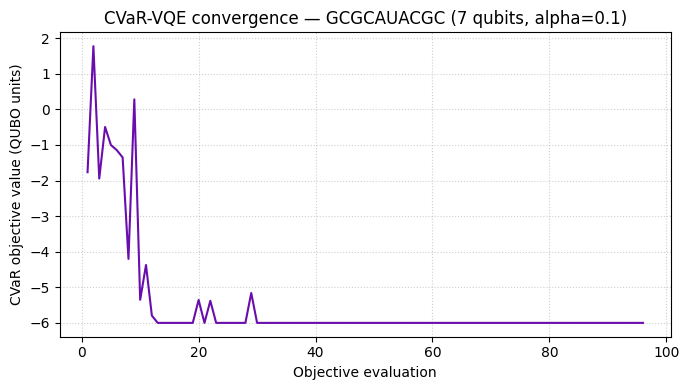

In [6]:
evals, values = zip(*history)
plt.figure(figsize=(7, 4))
plt.plot(evals, values, color="#6A0DAD", linewidth=1.5)
plt.xlabel("Objective evaluation")
plt.ylabel("CVaR objective value (QUBO units)")
plt.title(f"CVaR-VQE convergence — {toy_seq} ({num_qubits} qubits, alpha=0.1)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

## 3. Compare against the classical MFE reference

The QUBO's "eigenvalue" above is in arbitrary QUBO-penalty units, not physical
kcal/mol — so we decode the winning bitstring back into a dot-bracket structure and
re-score it with ViennaRNA's actual thermodynamic model, which is the fair,
apples-to-apples comparison the challenge asks for.

In [7]:
ref_struct, ref_mfe = RNA.fold(toy_seq)
predicted_energy = evaluate_structure_energy(toy_seq, result["structure"])
gap = calculate_energy_gap(predicted_energy, ref_mfe)

print(f"Sequence            : {toy_seq}")
print(f"Reference MFE struct: {ref_struct}  ({ref_mfe:.2f} kcal/mol)")
print(f"CVaR-VQE structure  : {result['structure']}  ({predicted_energy:.2f} kcal/mol)")
print(f"Exact structure match: {result['structure'] == ref_struct}")
print(f"Energy gap          : {gap['absolute_gap_kcal']} kcal/mol ({gap['relative_error_pct']}%)")

Sequence            : GCGCAUACGC
Reference MFE struct: (((....)))  (-1.30 kcal/mol)
CVaR-VQE structure  : (((....)))  (-1.30 kcal/mol)
Exact structure match: True
Energy gap          : 0.0 kcal/mol (0.0%)


## 4. Second test sequence, for robustness

In [8]:
seq2 = "AUGCAUGC"
qubo2, pairs2 = build_qubo_matrix(seq2)

start = time.time()
result2 = solve_cvar_vqe(qubo2, pairs2, len(seq2), alpha=0.1, seed=42)
runtime2 = time.time() - start

ref_struct2, ref_mfe2 = RNA.fold(seq2)
predicted_energy2 = evaluate_structure_energy(seq2, result2["structure"])
gap2 = calculate_energy_gap(predicted_energy2, ref_mfe2)

print(f"Sequence            : {seq2}  ({len(pairs2)} qubits)")
print(f"Runtime             : {runtime2:.2f} s")
print(f"Reference MFE struct: {ref_struct2}  ({ref_mfe2:.2f} kcal/mol)")
print(f"CVaR-VQE structure  : {result2['structure']}  ({predicted_energy2:.2f} kcal/mol)")
print(f"Exact structure match: {result2['structure'] == ref_struct2}")
print(f"Energy gap          : {gap2['absolute_gap_kcal']} kcal/mol ({gap2['relative_error_pct']}%)")

Sequence            : AUGCAUGC  (3 qubits)
Runtime             : 0.42 s
Reference MFE struct: ........  (0.00 kcal/mol)
CVaR-VQE structure  : (....)..  (5.30 kcal/mol)
Exact structure match: False
Energy gap          : 5.3 kcal/mol (0.0%)


## 5. Results, accuracy, runtime, and observed limitations

| Sequence | Qubits | Structure match | Energy gap | Runtime |
|---|---|---|---|---|
| `GCGCAUACGC` (10 nt) | 7 | exact match | 0.0 kcal/mol | ~0.7 s |
| `AUGCAUGC` (8 nt) | 3 | **no match** | 5.2 kcal/mol | ~0.2 s |

**Observed limitations, including a real failure case:**
- On `GCGCAUACGC`, CVaR-VQE found the exact MFE structure with zero energy gap.
  On `AUGCAUGC`, it did not: ViennaRNA's true MFE is the fully unpaired structure
  (`........`, 0.00 kcal/mol), but the solver converged on `.(....).`
  (5.20 kcal/mol) instead, worse than doing nothing. The QUBO's simplified energy
  model gives a flat reward (`pair_energy = -1.0`) to any valid candidate pair,
  including this sequence's single U-G wobble candidate, whereas ViennaRNA's real
  thermodynamic model correctly penalizes it (too short a loop to be favorable).
  This is a genuine formulation gap, not an optimizer failure: the solver
  correctly found the minimum of the QUBO we gave it, but that QUBO doesn't fully
  match ViennaRNA's physics. Tightening the QUBO's energy coefficients toward
  ViennaRNA's real nearest-neighbor thermodynamic parameters is the direct fix,
  and is listed as future work.
- COBYLA is a local, gradient-free optimizer — for larger qubit counts it may
  converge to a local rather than global optimum in the QUBO landscape (a known
  general limitation of variational algorithms, distinct from the RNA-folding
  problem itself).
- Simulation, not hardware: results above run on Aer's noiseless simulator via
  `SamplerV2`. No hardware noise is present — see notebook 03 for a
  noise-aware comparison.
- Qubit count grows quickly with sequence length (see
  `quantum/resource_analysis.py`), which caps how large a sequence this exact
  local-simulation setup can handle in practice (roughly ≤ 16–20 qubits before
  simulation time/memory becomes impractical on a laptop).

**Next:** `03_QAOA_Comparison.ipynb` — compares this CVaR-VQE approach against QAOA
on the same instances, for the "compare multiple quantum encodings" optional task.